## NLP Final
### Part 1: Article Clean-up and EDA
### Aren Mizuno
### March 12, 2026

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
import re
from google.colab import drive
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
# Mount
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cuda
torch.cuda.is_available()

True

In [4]:
# Load the dataset
df_news_final_project = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
df_news_final_project.shape

(199989, 5)

In [5]:
# Check the first few rows of the dataset
df_news_final_project.head(3)

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -..."


In [6]:
# Check for missing values
df_news_final_project.isnull().sum()

,0
url,0
date,0
language,0
title,0
text,0


There are no null values.

In [7]:
# Check the data types of the columns
df_news_final_project.dtypes

,0
url,object
date,object
language,object
title,object
text,object


In [8]:
# Count duplicate URLs
dup_url = df_news_final_project["url"].duplicated().sum()
dup_url

np.int64(0)

There are no duplicate urls.

In [9]:
# Count duplicate text
dup_text = df_news_final_project["text"].duplicated().sum()
dup_text

np.int64(494)

There are 494 duplicate texts, so I will drop duplicates.

In [10]:
# Drop duplicate text
df_news_final_project = df_news_final_project.drop_duplicates(subset=['text'])

In [11]:
# Count duplicate title
dup_title = df_news_final_project["title"].duplicated().sum()
dup_title

np.int64(35190)

There are 35190 duplicate titles, so I will drop duplicates.

In [12]:
# Save count
post_duplicate_drop_count = len(df_news_final_project)
post_duplicate_drop_count

199495

In [13]:
# Drop duplicate title
df_news_final_project = df_news_final_project.drop_duplicates(subset=['title'])

In [14]:
df_news_final_project

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -..."
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...
...,...,...,...,...,...
199983,https://www.wypr.org/2024-10-08/researchers-wh...,2024-10-09,en,Researchers who helped lay the groundwork for ...,\n\nResearchers who helped lay the groundwork ...
199984,https://www.zawya.com/en/press-release/compani...,2025-10-13,en,Ejada Systems signs MoU with Dyna.Ai to enhanc...,Ejada Systems signs MoU with Dyna.Ai to enhanc...
199985,https://www.zawya.com/en/press-release/compani...,2025-03-13,en,UNDP and e& strengthen AI collaboration for su...,UNDP and e& strengthen AI collaboration for su...
199986,https://www.zawya.com/en/press-release/events-...,2025-06-05,en,Harnessing AI to make energy poverty history: ...,Harnessing AI to make energy poverty history: ...


In [15]:
# Check how many start with https://
https_count = df_news_final_project["url"].str.startswith("http", na=False).sum()

total_urls = len(df_news_final_project)

print("Total URLs:", total_urls)
print("URLs starting with http", https_count)

Total URLs: 164305
URLs starting with http 164305


All URLs begin with the HTTP/HTTPS protocol, indicating consistent formatting and no malformed or relative links. This supports the structural integrity of the dataset and suggests reliable data ingestion.

In [16]:
# Unique language values
df_news_final_project["language"].unique()

array(['en'], dtype=object)

All language values are in 'en' so this is unimportant and we can drop this column.

In [17]:
df_news_final_project = df_news_final_project.drop(columns=["language"])

In [18]:
# Convert to datetime
df_news_final_project["date"] = pd.to_datetime(
    df_news_final_project["date"],
    errors="coerce"
)

print("Date range:")
print("Min:", df_news_final_project["date"].min())
print("Max:", df_news_final_project["date"].max())

Date range:
Min: 2022-01-01 00:00:00
Max: 2026-02-10 00:00:00


In [19]:
# Count articles per day
articles_per_day = (
    df_news_final_project
    .groupby(df_news_final_project["date"].dt.date)
    .size()
)

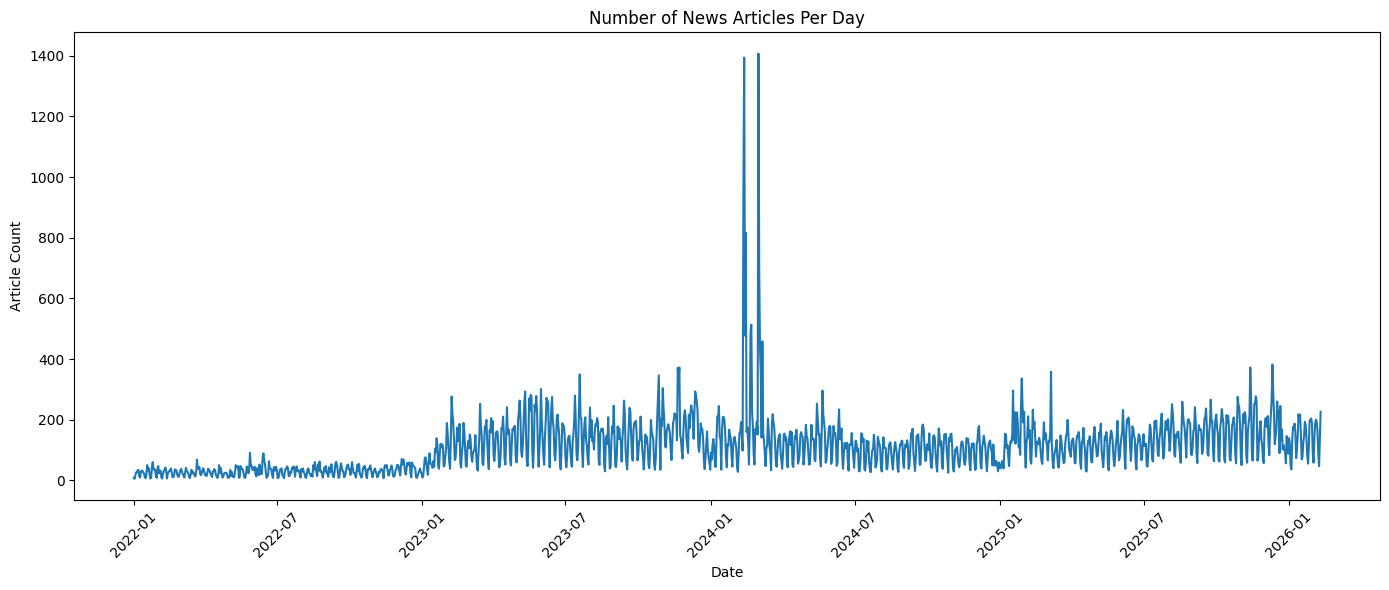

In [20]:
# Plot articles by date
plt.figure(figsize=(14,6))
plt.plot(articles_per_day.index, articles_per_day.values)
plt.title("Number of News Articles Per Day")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The figure displays the daily number of news articles published from early 2022 through early 2026 and reveals several clear patterns. In 2022, article volume is relatively low and stable, generally ranging between about 20 and 120 articles per day. In 2023, there is a noticeable upward shift, with daily counts frequently reaching 150 to 400, indicating increased media activity or broader coverage. The most striking feature occurs in early 2024, where there are extreme spikes approaching 1,500–1,600 articles in a single day, far exceeding typical levels and suggesting either a major global event or a potential data aggregation anomaly. After this surge, article counts fall back to more typical levels throughout mid-to-late 2024, mostly between 100 and 200 per day. In 2025, the series shows a gradual upward trend again, stabilizing at moderately higher levels than 2022.

In [21]:
# Clean text and title
def clean_text(s):
    s = re.sub(r"http\S+", " ", s) # remove links
    s = re.sub(r"\s+", " ", s).strip() # remove white space
    return s

df_news_final_project["title"] = df_news_final_project["title"].map(clean_text)
df_news_final_project["text"] = df_news_final_project["text"].map(clean_text)

In [22]:
# Count words as sequences of non-whitespace chars (save RAM)
df_news_final_project["text_word_count"]  = df_news_final_project["text"].str.count(r"\S+").astype("int32")
df_news_final_project["title_word_count"] = df_news_final_project["title"].str.count(r"\S+").astype("int32")

print("Text word count stats")
print("Average:", df_news_final_project["text_word_count"].mean())
print("Min:", df_news_final_project["text_word_count"].min())
print("Max:", df_news_final_project["text_word_count"].max())

print("\nTitle word count stats")
print("Average:", df_news_final_project["title_word_count"].mean())
print("Min:", df_news_final_project["title_word_count"].min())
print("Max:", df_news_final_project["title_word_count"].max())

Text word count stats
Average: 1282.7895681811265
Min: 4
Max: 39964

Title word count stats
Average: 13.898828398405405
Min: 1
Max: 1325


In [23]:
df_news_final_project[["text_word_count", "title_word_count"]].describe()

,text_word_count,title_word_count
count,164305.000000,164305.000000
mean,1282.789568,13.898828
std,1014.947887,6.173933
min,4.000000,1.000000
25%,720.000000,11.000000
50%,1099.000000,13.000000
75%,1622.000000,16.000000
max,39964.000000,1325.000000


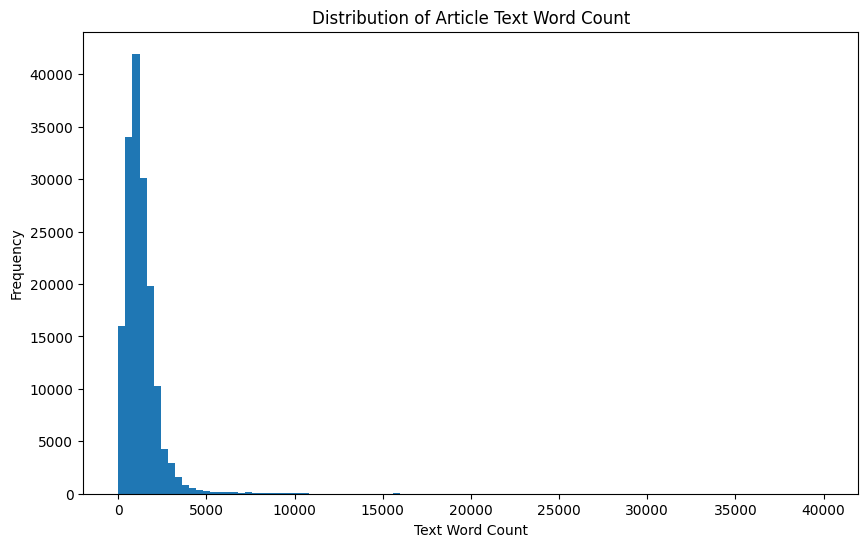

In [24]:
# Plot text word count distribution
plt.figure(figsize=(10,6))
plt.hist(df_news_final_project["text_word_count"], bins=100)
plt.title("Distribution of Article Text Word Count")
plt.xlabel("Text Word Count")
plt.ylabel("Frequency")
plt.show()

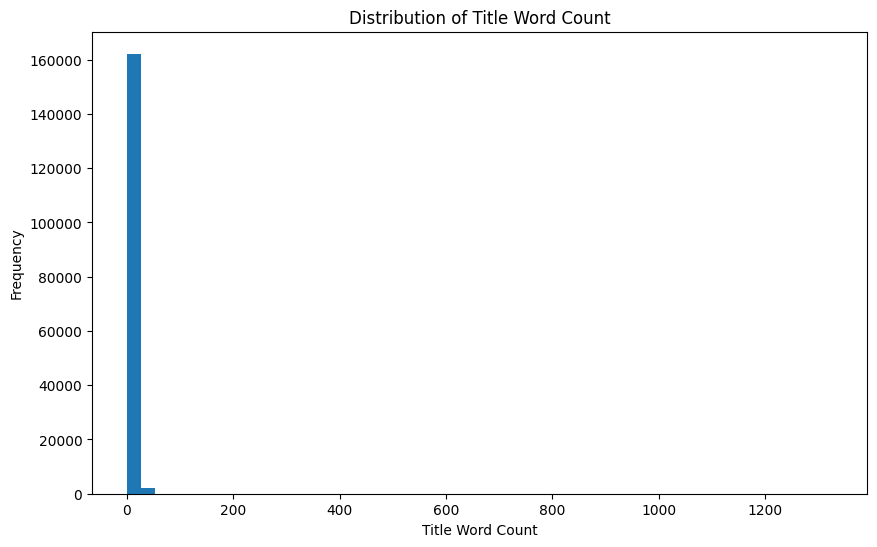

In [25]:
# Plot title word count distribution
plt.figure(figsize=(10,6))
plt.hist(df_news_final_project["title_word_count"], bins=50)
plt.title("Distribution of Title Word Count")
plt.xlabel("Title Word Count")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_1629/1301095040.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


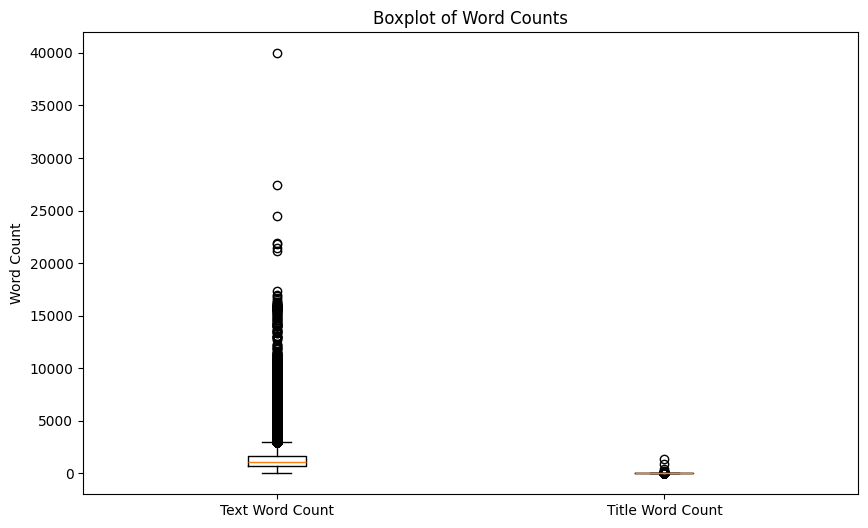

In [26]:
# Boxplot word count
plt.figure(figsize=(10,6))

plt.boxplot([
    df_news_final_project["text_word_count"],
    df_news_final_project["title_word_count"]
], labels=["Text Word Count", "Title Word Count"])

plt.title("Boxplot of Word Counts")
plt.ylabel("Word Count")
plt.show()

The boxplots and histograms show that article text length is highly right-skewed, with most articles concentrated in a moderate range but a long tail of extremely long pieces. The median text word count appears well below the maximum, while numerous high-end outliers extend up to around 40,000 words, indicating substantial variability in article length. In contrast, title word counts are tightly clustered at much smaller values, with relatively limited spread and only a few extreme outliers. Overall, the distributions suggest that while titles are consistently short and uniform, article texts vary considerably in length, which has important implications for transformer-based modeling due to token limits and potential truncation of longer documents.

In [27]:
# Text IQR
Q1_text = df_news_final_project["text_word_count"].quantile(0.25)
Q3_text = df_news_final_project["text_word_count"].quantile(0.75)
IQR_text = Q3_text - Q1_text

text_lower = max(0, Q1_text - 1.5 * IQR_text)
text_upper = Q3_text + 1.5 * IQR_text

# Title IQR
Q1_title = df_news_final_project["title_word_count"].quantile(0.25)
Q3_title = df_news_final_project["title_word_count"].quantile(0.75)
IQR_title = Q3_title - Q1_title

title_lower = max(0, Q1_title - 1.5 * IQR_title)
title_upper = Q3_title + 1.5 * IQR_title

print("Text bounds:", text_lower, "to", text_upper)
print("Title bounds:", title_lower, "to", title_upper)

Text bounds: 0 to 2975.0
Title bounds: 3.5 to 23.5


In [28]:
# Apply filtering
mask = (
    (df_news_final_project["text_word_count"] >= text_lower) &
    (df_news_final_project["text_word_count"] <= text_upper) &
    (df_news_final_project["title_word_count"] >= title_lower) &
    (df_news_final_project["title_word_count"] <= title_upper)
)

print("Total rows:", len(df_news_final_project))
print("Kept:", mask.sum())
print("Dropped:", (~mask).sum())

df_news_final_project = df_news_final_project[mask]

Total rows: 164305
Kept: 152490
Dropped: 11815


In [29]:
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    max_features=10000,
    token_pattern=r"\b[a-zA-Z]+\b"  # only letters, no numbers
)

X = vectorizer.fit_transform(df_news_final_project["text"])

word_counts = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

freq_df = (
    pd.DataFrame({"word": words, "count": word_counts})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

In [30]:
# See words with large counts
freq_df.head(90)

,word,count
0,ai,2062246
1,s,1706831
2,news,928671
3,new,563361
4,data,482455
...,...,...
85,human,116492
86,twitter,116395
87,rights,115999
88,social,113061


In [31]:
# See words around count = 100000
idx = freq_df[freq_df["count"] < 100000].index[0]
freq_df.iloc[idx-10:idx+11]

,word,count
102,including,106131
103,growth,106117
104,community,105200
105,weather,104749
106,science,104388
107,management,104381
108,development,103131
109,article,102451
110,systems,101630
111,education,100958


In [32]:
# Total rows pre drop
pre_common_word_drop = len(df_news_final_project)

# Columns corresponding to words with count >= 100000
cols = freq_df[freq_df["count"] >= 100000].index

# Keep rows containing at least one of those words
mask = (X[:, cols].sum(axis=1).A1 > 0)

df_news_final_project = df_news_final_project[mask].copy()

# Total rows after drop
post_common_word_drop = len(df_news_final_project)

print("Pre drop rows:", pre_common_word_drop)
print("Post drop rows:", post_common_word_drop)
print("Dropped:", pre_common_word_drop - post_common_word_drop)
print("Percent dropped:", round((pre_common_word_drop - post_common_word_drop) / pre_common_word_drop * 100, 2), "%")

Pre drop rows: 152490
Post drop rows: 136233
Dropped: 16257
Percent dropped: 10.66 %


In [33]:
# Drop EDA columns
df_news_final_project = df_news_final_project.drop(
    columns=["text_word_count", "title_word_count"],
    errors="ignore"
)

In [34]:
# Save cleaned version as parquet
save_path = "/content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/news_final_project_cleaned.parquet"

# Create full directory tree if missing
os.makedirs(os.path.dirname(save_path), exist_ok=True)

df_news_final_project.to_parquet(
    save_path,
    engine="pyarrow",
    compression="snappy"
)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/news_final_project_cleaned.parquet
